# Chapter7. 군집화

## 01.K-평균 알고리즘의 이해

K평균: 군집 중심점이라는 특정한 임의 지점을 선택해 해당 중심에 가장 가까운 포인트들을 선택하는 군집화 기법

- 장점: 일반적으로 가장 많이 활용, 쉽고 간결한 알고리즘
- 단점: 거리 기반 알고리즘으로 속성개수가 많아지면 정확도 떨어짐, 반복 수행하는데 횟수가 많으면 느려짐, 몇개 클러스터 선택할 지 가이드 어려움 

### 사이킷런 KMeans클래스 소개

In [2]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=8, init='k-means++', n_init=10, max_iter=300, tol=0.0001,
    verbose=0, random_state=None, copy_x=True
)

초기화 파라미터 중 가장 중요한 파라미터:n_cluster, 군집화할 개수, 군집 중심점의 개수를 의미함
init은 초기에 군집 중심점의 좌표를 설정할 방식을 말함. 
max_iter은 최대 반복 횟수

### K- 평균을 이용한 붓꽃 데이터셋 군집화

In [3]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline
iris=load_iris()
irisDF=pd.DataFrame(data=iris.data,columns=['sepal_length','sepal_width','petal_length','petal_width'])
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


데이터셋을 3개그룹으로 군집화함

In [6]:
kmeans=KMeans(n_clusters=3,init='k-means++',max_iter=300,random_state=0)
kmeans.fit(irisDF)

C:\Users\Yeeun\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Yeeun\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3, random_state=0)

In [7]:
print(kmeans.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


라벨값이 012로됨-> 1,2,3군집에 속함을 의미

실제 분류값인 타겟과 군집화 분류값인 클러스터 레벨로 적용해 타겟,클러스터 값개수 비교

In [8]:
irisDF['target']=iris.target
irisDF['cluster']=kmeans.labels_
iris_result=irisDF.groupby(['target','cluster'])['sepal_length'].count()
print(iris_result)

target  cluster
0       1          50
1       0          48
        2           2
2       0          14
        2          36
Name: sepal_length, dtype: int64


분류 타깃이 0값인 데이터는 1번으로 잘 그루핑됨
타겟 2값 데이터는 0번에 14개 2번에 36개로 분산됨

In [13]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_transformed=pca.fit_transform(iris.data)

irisDF['pca_x']=pca_transformed[:,0]
irisDF['pca_y']=pca_transformed[:,1]
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,-2.888991,-0.144949


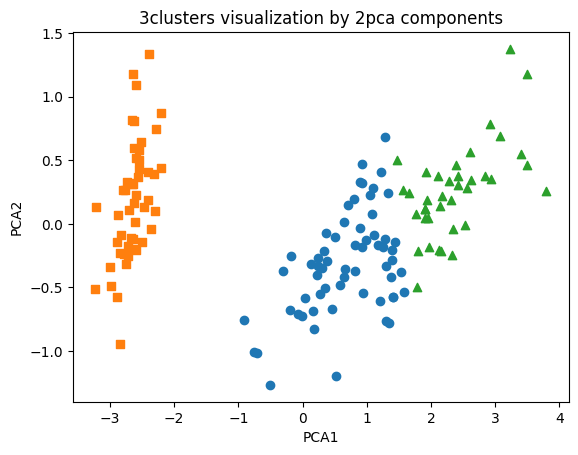

In [15]:
marker0_ind=irisDF[irisDF['cluster']==0].index
marker1_ind=irisDF[irisDF['cluster']==1].index
marker2_ind=irisDF[irisDF['cluster']==2].index

plt.scatter(x=irisDF.loc[marker0_ind,'pca_x'],y=irisDF.loc[marker0_ind,'pca_y'],marker='o')
plt.scatter(x=irisDF.loc[marker1_ind,'pca_x'],y=irisDF.loc[marker1_ind,'pca_y'],marker='s')
plt.scatter(x=irisDF.loc[marker2_ind,'pca_x'],y=irisDF.loc[marker2_ind,'pca_y'],marker='^')

plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('3clusters visualization by 2pca components')
plt.show()

네모는 명확히 분리되어 있지 않음,cluster0,1 속성 위치 자체가 명확히 분뤼되기 어려움

### 군집화 알고리즘 테스트를 위한 데이터 생성

- make_blobs(): 개별군집의 중심점,표준 편차 제어 기능 추가
- make_classification():노이즈포함한 데이터만드는데 유용

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
%matplotlib inline

X,y=make_blobs(n_samples=200,n_features=2,centers=3,cluster_std=0.8,random_state=0)
print(X.shape,y.shape)

unique,counts=np.unique(y,return_counts=True)
print(unique,counts)

(200, 2) (200,)
[0 1 2] [67 67 66]


In [22]:
import pandas as pd
clusterDF=pd.DataFrame(data=X,columns=['ftr1','ftr2'])
clusterDF['target']= y
clusterDF.head(3)

,ftr1,ftr2,target
0,-1.692427,3.622025,2
1,0.697940,4.428867,0
2,1.100228,4.606317,0


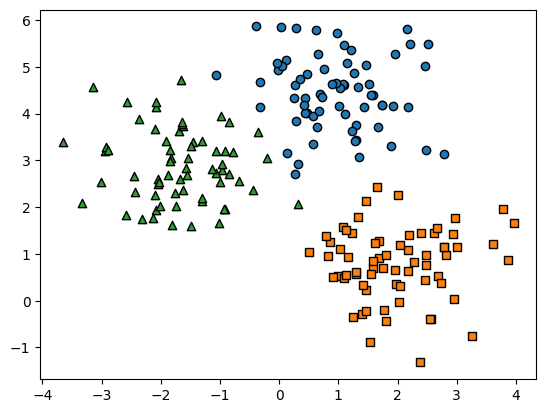

In [25]:
target_list=np.unique(y)
markers=['o','s','^','P','D','H','x']
for target in target_list:
    target_cluster=clusterDF[clusterDF['target']==target]
    plt.scatter(x=target_cluster['ftr1'],y=target_cluster['ftr2'],edgecolor='k',
                marker=markers[target])
plt.show()

C:\Users\Yeeun\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Yeeun\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


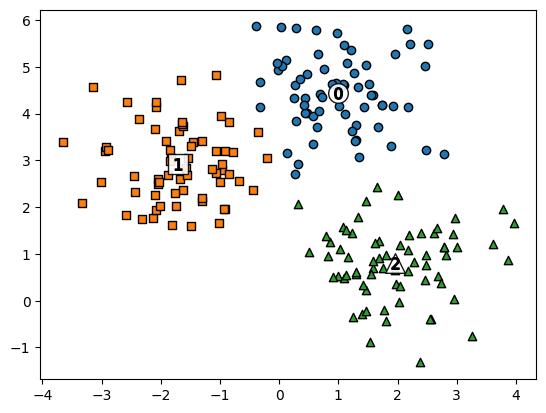

In [30]:
kmeans=KMeans(n_clusters=3,init='k-means++',max_iter=200,random_state=0)
cluster_labels=kmeans.fit_predict(X)
clusterDF['kmeans_label']=cluster_labels

centers=kmeans.cluster_centers_
unique_labels=np.unique(cluster_labels)
markers=['o','s','^','P','D','H','x']

for label in unique_labels:
    label_cluster=clusterDF[clusterDF['kmeans_label']==label]
    center_x_y=centers[label]
    plt.scatter(x=label_cluster['ftr1'],y=label_cluster['ftr2'],edgecolor='k',
            marker=markers[label])

    plt.scatter(x=center_x_y[0],y=center_x_y[1],s=200,color='white',
                alpha=0.9,edgecolor='k',marker=markers[label])
    plt.scatter(x=center_x_y[0],y=center_x_y[1],s=70,color='k',edgecolor='k',
                marker='$%d$' %label)
plt.show()

In [31]:
print(clusterDF.groupby('target')['kmeans_label'].value_counts())

target  kmeans_label
0       0               66
        1                1
1       2               67
2       1               65
        2                1
Name: count, dtype: int64


- cluster_std가 작을수록 군집 중심에 데이터 모여있고 클수록 데이터 퍼져있음

## 02. 군집 평가(Cluster Evaluation)

군집화가 효율적으로 잘 됐는지 평가할 수 있는 지표: 실루엣 분석

### 실루엣 분석의 개요

각 군집간의 거리가 얼마나 효율적으로 분리되어 있는 지 나타냄
= 다른 군집과의 거리는 떨어져 있고 동일 군집끼리의 데이터는 서로 잘뭉쳐짐 

군집화 잘될수록 개별군집은 비슷한 정도의 여유를 가지고 떨어져있음

- 실루엣계수를 기반으로 함 개별 데이터가 가지는 군집화 지표

- 1에서 1까지의 값을 가지고 1로 가까워질수록 근처 군집과 더 멀리떨어져있다는 것
- 0에 가까울수록 근처 군집과 가까워짐
- -값은 아예 다른 군집 데이터 포인트가 할당됨

좋은 군집화가 되려면? 1) 전체 실루엣 계수의 평균값이 0에서1가짐, 1에 가까울수록 좋다

2) 개별 군집의 평균값 편차가 크지 않아야함

### 붓꽃 데이터 셋을 이용한 군집평가

In [34]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_samples,silhouette_score
import matplotlib.pyplot as plt
import numpy as np

In [37]:
import pandas as pd
%matplotlib inline

iris=load_iris()
feature_names=['sepal_length','sepal_width','petal_length','petal_width']
irisDF=pd.DataFrame(data=iris.data,columns=feature_names)
kmeans=KMeans(n_clusters=3,init='k-means++',max_iter=300,random_state=0).fit(irisDF)
irisDF['cluster']=kmeans.labels_

score_samples=silhouette_samples(iris.data,irisDF['cluster'])
print('silhouette_samples() return값의 shpae',score_samples.shape)

irisDF['silhouette_coeff']=score_samples

average_score=silhouette_score(iris.data,irisDF['cluster'])
print('붓꽃 데이터 세트 silhouette analysis score:{0:.3f}'.format(average_score))
irisDF.head(3)

silhouette_samples() return값의 shpae (150,)
붓꽃 데이터 세트 silhouette analysis score:0.553


C:\Users\Yeeun\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Yeeun\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,sepal_length,sepal_width,petal_length,petal_width,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,1,0.852955
1,4.9,3.0,1.4,0.2,1,0.815495
2,4.7,3.2,1.3,0.2,1,0.829315


1번 군집이 아닌 다른 군집은 실루엣 계수가 낮음-> 전체 평균 실루엣계수값 0.553

군집별 평균 실루엣 계수 값으로 확인해보면

In [38]:
irisDF.groupby('cluster')['silhouette_coeff'].mean()

cluster
0    0.417320
1    0.798140
2    0.451105
Name: silhouette_coeff, dtype: float64

1번 클러스터는 0.79인 반면 0번은 0.41,2번은 0.45로 평균값이 낮음

### 군집별 평균 실루엣 계수의 시각화를 통한 군집 개수의 최적화 방법

여러 개의 군집 개수가 주어졌을 때, 평균 실루엣 계수로 군집 개수를 최적화 하는 방법

- case 1) 주어진 데이터에 대해 군집 개수 2개를 정했을 때

개별 군집에 속하는 데이터 실루엣계수를 2차원으로 나타냄(x축:실루엣계수,y축:개별군집과 속하는데이터)
-> 1번 군집의 모든 데이터는 평균 실루엣 계수값 이상이지만 2번 군집의 경우 평균보다 적은 데이터값이 많음

- case 2) 군집 개수가 3개일 경우

전체 데이터의 평균 실루엣 계수값: 0.588,1번,2번 군집은 평균보다 높은 실루엣계수지만 0번은 평균보다 모두 낮음

- case 3) 군집 개수가 4개인 경우

평균 실루엣 계수 값: 0.65, 개별 군집의 평균 실루엣계수값은 비교적 균일함

1번군집의 경우 모든 데이터 평균보다 높은 계수값, 0,2번은 절반 이상이 평균보다 높은 계수값, 3번 군집은 1/3만 평균보다 높은 계수값가짐

군집이 2개인 경우보다는 평균 실루엣계수가 작지만 4개인 경우가 가장 이상적인 군집화 개수로 판단할 수 있음

- visualize_silhouette()

ex. visualize_silhouette([2,3,4,5],X_features) #피처 데이터셋 X_feature에 대해 군집이 2개/3개/4개/5개일 때 평균 실루엣 계수값 구하는법

In [44]:
from sklearn.datasets import make_blobs
X,y=make_blobs(n_samples=500,n_features=2,centers=4,cluster_std=1,
                center_box=(-10.0,10,0),shuffle=True,random_state=1)

visualize_silhouette([2,3,4,5,],x)

NameError: name 'visualize_silhouette' is not defined

-> 4개의 군집일때 가장 최적이 됨

In [46]:
from sklearn.datasets import load_iris
iris=load_iris()
visualize_silhouette([2,3,4,5],iris.data)

NameError: name 'visualize_silhouette' is not defined

-> k-평균으로 군집화할때는 군집화 2개가 가장 좋음